# HLV Metrics Tutorial (Intuition + Extremes)

This notebook is designed for toolkit users to understand each HLV metric **visually and concretely**:

- when it is minimum,
- when it is maximum (or very large),
- and how to interpret "small" vs "large" values.

## 1) Setup

We use the exact implementations from `hlv_toolkits.eval.metrics`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hlv_toolkits.eval.metrics import (
    compute_tvd,
    compute_jsd,
    compute_kl,
    compute_cross_entropy,
    compute_euclidean_distance,
    compute_soft_micro_f1,
    compute_soft_macro_f1,
    compute_distance_correlation,
)

np.set_printoptions(precision=4, suppress=True)

/mounts/Users/cisintern/xcheng/nli-toolkits/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Controlled Toy Data

We create one human distribution matrix and five prediction variants:

- `identical`: exact match (best case for pointwise metrics)
- `small_shift`: tiny perturbation
- `confident_wrong`: puts high mass on opposite classes
- `uniform`: always predicts `[1/3, 1/3, 1/3]`

In [2]:
human = np.array([
    [0.90, 0.08, 0.02],
    [0.70, 0.20, 0.10],
    [0.40, 0.40, 0.20],
    [0.34, 0.33, 0.33],
    [0.10, 0.20, 0.70],
    [0.02, 0.08, 0.90],
    [0.33, 0.33, 0.34],
    [0.25, 0.50, 0.25],
    [0.20, 0.60, 0.20]
], dtype=float)

pred_identical = human.copy()

pred_small_shift = np.array([
    [0.88, 0.10, 0.02],
    [0.68, 0.22, 0.10],
    [0.38, 0.42, 0.20],
    [0.32, 0.34, 0.34],
    [0.12, 0.18, 0.70],
    [0.04, 0.06, 0.90],
    [0.30, 0.36, 0.34],
    [0.22, 0.48, 0.30],
    [0.18, 0.62, 0.20]
], dtype=float)

pred_confident_wrong = np.array([
    [0.02, 0.08, 0.90],
    [0.10, 0.20, 0.70],
    [0.20, 0.40, 0.40],
    [0.33, 0.33, 0.34],
    [0.70, 0.20, 0.10],
    [0.90, 0.08, 0.02],
    [0.34, 0.33, 0.33],
    [0.25, 0.50, 0.25],
    [0.20, 0.60, 0.20]
], dtype=float)

pred_uniform = np.full_like(human, 1.0 / 3.0)

cases = {
    "identical": pred_identical,
    "small_shift": pred_small_shift,
    "confident_wrong": pred_confident_wrong,
    "uniform": pred_uniform,
}

for name, pred in cases.items():
    print(name, "row sums:", np.round(pred.sum(axis=1), 4))

identical row sums: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
small_shift row sums: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
confident_wrong row sums: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
uniform row sums: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 3) One Summary Table First

This gives a full picture before we zoom in per metric.

In [3]:
def summarize_case(name, pred, target):
    return {
        "case": name,
        "tvd": float(compute_tvd(pred, target).mean()),
        "jsd": float(compute_jsd(pred, target, base=2).mean()),
        "kl": float(compute_kl(target, pred).mean()),  # KL(human || pred)
        "ce": float(compute_cross_entropy(target, pred).mean()),
        "l2": float(compute_euclidean_distance(pred, target).mean()),
        "soft_micro_f1": float(compute_soft_micro_f1(pred, target)),
        "soft_macro_f1": float(compute_soft_macro_f1(pred, target)),
        "distance_correlation": float(compute_distance_correlation(pred, target)),
    }

rows = [summarize_case(name, pred, human) for name, pred in cases.items()]

headers = [
    "case", "tvd", "jsd", "kl", "ce", "l2",
    "soft_micro_f1", "soft_macro_f1", "distance_correlation"
]

print(" | ".join(headers))
for r in rows:
    print(" | ".join(f"{r[h]:.4f}" if h != "case" else r[h] for h in headers))

case | tvd | jsd | kl | ce | l2 | soft_micro_f1 | soft_macro_f1 | distance_correlation
identical | 0.0000 | 0.0000 | 0.0000 | 0.8440 | 0.0000 | 1.0000 | 1.0000 | 1.0000
small_shift | 0.0244 | 0.0314 | 0.0032 | 0.8471 | 0.0331 | 0.9756 | 0.9754 | 0.9989
confident_wrong | 0.3533 | 0.3576 | 1.0193 | 1.8633 | 0.4997 | 0.6467 | 0.6624 | 1.0000
uniform | 0.2719 | 0.2474 | 0.2546 | 1.0986 | 0.3345 | 0.7281 | 0.7291 | 0.0000


## 4) TVD / JSD / L2 (Distance-style Metrics)

Interpretation:
- Minimum is `0` when prediction equals human distribution.
- Larger values mean larger pointwise mismatch.
- TVD and JSD are bounded in `[0, 1]` (`base=2` for JSD).

In [4]:
for metric_name, fn in [
    ("TVD mean", lambda p: compute_tvd(p, human).mean()),
    ("JSD mean", lambda p: compute_jsd(p, human, base=2).mean()),
    ("L2 mean",  lambda p: compute_euclidean_distance(p, human).mean()),
]:
    print(f"{metric_name}")
    vals = [(name, float(fn(pred))) for name, pred in cases.items()]
    vals = sorted(vals, key=lambda x: x[1])  # lower is better
    for k, v in vals:
        print(f"  {k:16s} {v:.4f}")

TVD mean
  identical        0.0000
  small_shift      0.0244
  uniform          0.2719
  confident_wrong  0.3533
JSD mean
  identical        0.0000
  small_shift      0.0314
  uniform          0.2474
  confident_wrong  0.3576
L2 mean
  identical        0.0000
  small_shift      0.0331
  uniform          0.3345
  confident_wrong  0.4997


## 5) KL and Cross-Entropy

In this toolkit we usually report `KL(human || pred)`.

- Minimum KL is `0` only at exact match.
- CE can be not `0` even at exact match
- KL / CE can become very large if model gives near-zero probability to human-supported labels.
- KL is not symmetric.

In [5]:
one_h = human[[0]]
one_p = pred_small_shift[[0]]

print("KL(human || pred):", float(compute_kl(one_h, one_p)[0]))
print("KL(pred || human):", float(compute_kl(one_p, one_h)[0]))

print("KL mean ranking (lower is better)")
vals = sorted(((name, float(compute_kl(human, pred).mean())) for name, pred in cases.items()), key=lambda x: x[1])
for k, v in vals:
    print(f"  {k:16s} {v:.4f}")

print("Cross entropy mean ranking (lower is better)")
vals = sorted(((name, float(compute_cross_entropy(human, pred).mean())) for name, pred in cases.items()), key=lambda x: x[1])
for k, v in vals:
    print(f"  {k:16s} {v:.4f}")

KL(human || pred): 0.002374086161715968
KL(pred || human): 0.002538241981609398
KL mean ranking (lower is better)
  identical        0.0000
  small_shift      0.0032
  uniform          0.2546
  confident_wrong  1.0193
Cross entropy mean ranking (lower is better)
  identical        0.8440
  small_shift      0.8471
  uniform          1.0986
  confident_wrong  1.8633


## 6) Soft F1 Metrics (Overlap-style)

Interpretation:
- Maximum is `1` at exact overlap.
- Minimum is `0` at zero overlap.
- Larger is better.

In [6]:
print("soft_micro_f1 ranking (higher is better)")
vals = sorted(((name, float(compute_soft_micro_f1(pred, human))) for name, pred in cases.items()), key=lambda x: x[1], reverse=True)
for k, v in vals:
    print(f"  {k:16s} {v:.4f}")

print("soft_macro_f1 ranking (higher is better)")
vals = sorted(((name, float(compute_soft_macro_f1(pred, human))) for name, pred in cases.items()), key=lambda x: x[1], reverse=True)
for k, v in vals:
    print(f"  {k:16s} {v:.4f}")

soft_micro_f1 ranking (higher is better)
  identical        1.0000
  small_shift      0.9756
  uniform          0.7281
  confident_wrong  0.6467
soft_macro_f1 ranking (higher is better)
  identical        1.0000
  small_shift      0.9754
  uniform          0.7291
  confident_wrong  0.6624


## 7) Distance Correlation (Global Structure) + Ternary Visualization

Distance correlation captures **global geometry** of point clouds, not row-by-row closeness.

To make this intuitive, we also visualize each case with
`save_distribution_ternary_plot` from `hlv_toolkits.visualization.plots`.

You can compare:
- where model points sit in the simplex,
- where human points sit,
- and how this relates to the distance-correlation score.


In [7]:
print("distance_correlation ranking (higher is better)")
vals = sorted(((name, float(compute_distance_correlation(pred, human))) for name, pred in cases.items()), key=lambda x: x[1], reverse=True)
for k, v in vals:
    print(f"  {k:16s} {v:.4f}")

distance_correlation ranking (higher is better)
  identical        1.0000
  confident_wrong  1.0000
  small_shift      0.9989
  uniform          0.0000


In the `confident_wrong` case, the model places high probability mass on the opposite class instead of the correct one. Although the prediction is semantically incorrect, the probability vector is effectively a permutation of the original distribution, preserving the relative distances between points.

As a result, the global geometry in the stays the same (as show in the ternary plot bewlow), and the distance-correlation score is 1.

Saved: metrics_tutorial_ternary/ternary_identical.png


/mounts/Users/cisintern/xcheng/nli-toolkits/.venv/lib/python3.12/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


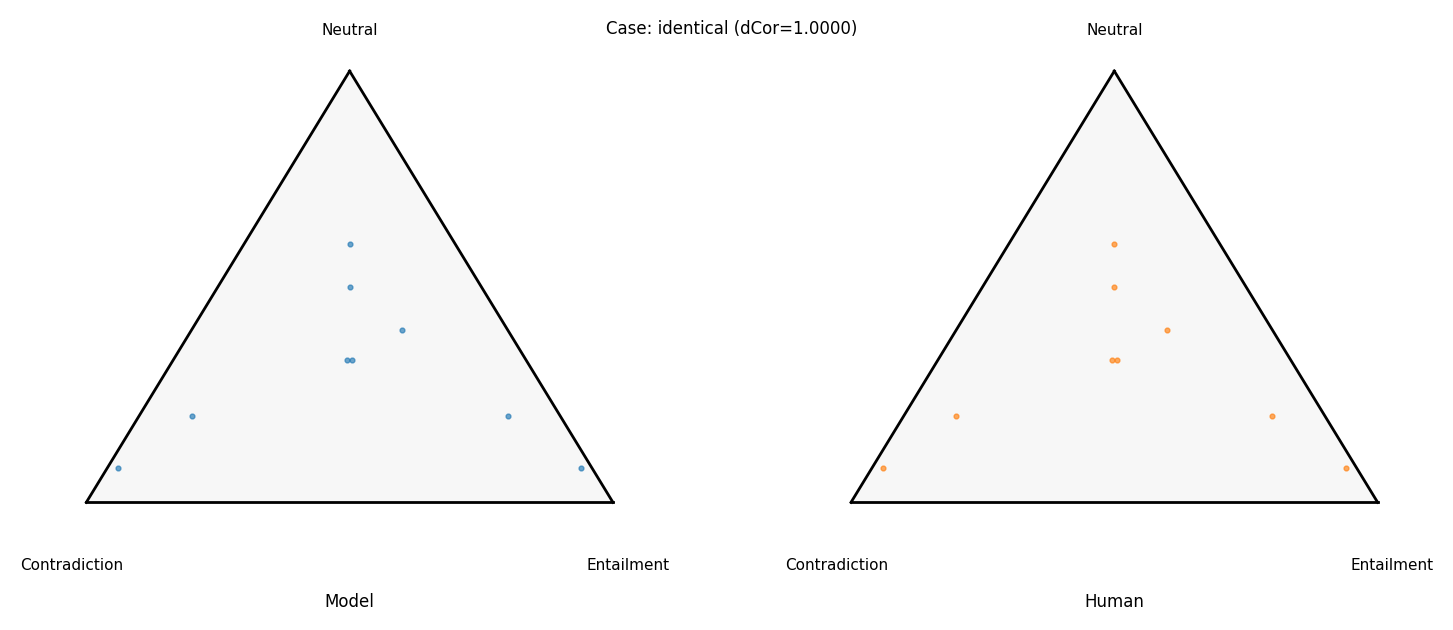

Saved: metrics_tutorial_ternary/ternary_small_shift.png


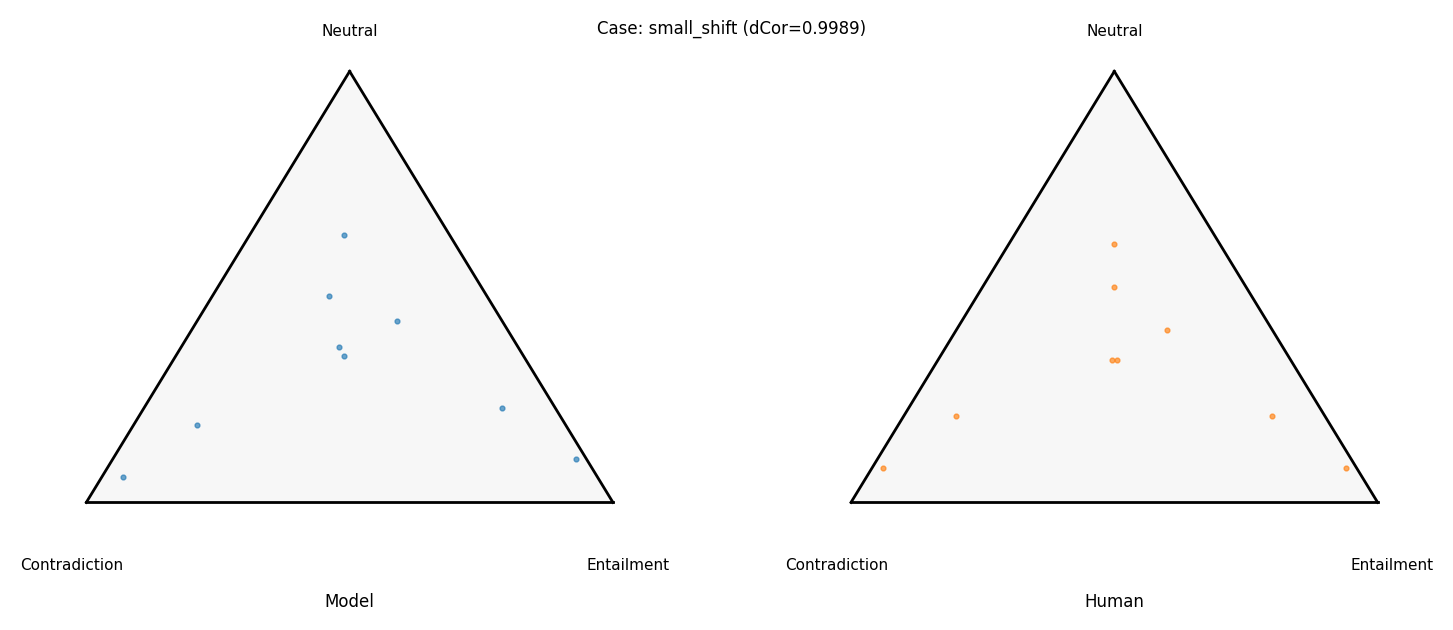

Saved: metrics_tutorial_ternary/ternary_confident_wrong.png


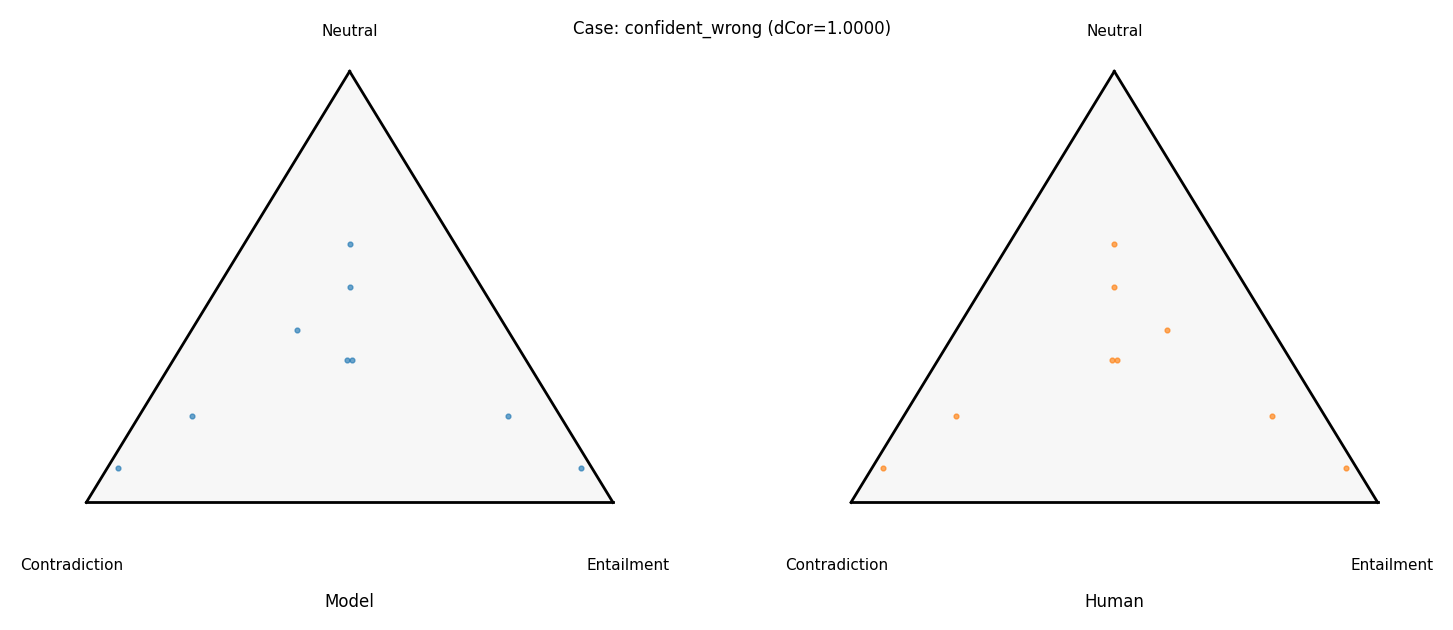

Saved: metrics_tutorial_ternary/ternary_uniform.png


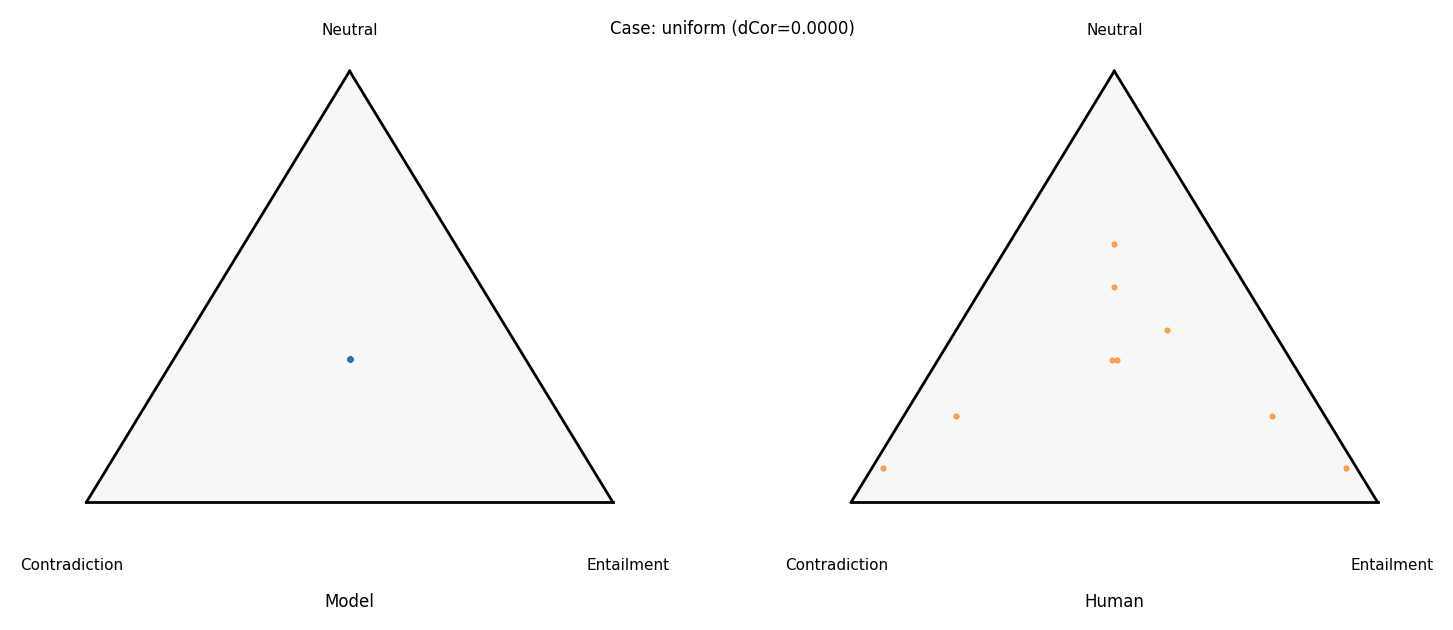

In [8]:
from pathlib import Path
from IPython.display import Image, display
from hlv_toolkits.visualization import save_distribution_ternary_plot

out_dir = Path('metrics_tutorial_ternary')
out_dir.mkdir(parents=True, exist_ok=True)

for name, pred in cases.items():
    out_path = out_dir / f'ternary_{name}.png'
    ok = save_distribution_ternary_plot(
        model_distributions=pred,
        human_distributions=human,
        output_path=out_path,
        distribution_source='both',
        title=f'Case: {name} (dCor={compute_distance_correlation(pred, human):.4f})',
    )
    if ok:
        print(f'Saved: {out_path}')
        display(Image(filename=str(out_path)))
    else:
        print('Ternary plotting skipped: missing optional dependency (matplotlib/python-ternary).')
        break


## 8) Exact Extreme Values (Single Sample)

Opposite one-hot vectors show clear boundaries for several metrics.

In [9]:
h = np.array([[1.0, 0.0, 0.0]])
p = np.array([[0.0, 1.0, 0.0]])

print("TVD:", compute_tvd(p, h)[0].round(4))
print("JSD (base=2):", compute_jsd(p, h, base=2)[0].round(4))
print("KL(h||p):", compute_kl(h, p)[0].round(4))
print("CrossEntropy(h,p):", compute_cross_entropy(h, p)[0].round(4))
print("L2:", compute_euclidean_distance(p, h)[0].round(4))
print("soft_micro_f1:", compute_soft_micro_f1(p, h).round(4))

TVD: 1.0
JSD (base=2): 1.0
KL(h||p): 27.631
CrossEntropy(h,p): 27.631
L2: 1.4142
soft_micro_f1: 0.0


Identical vectors show clear boundaries for several metrics.

Note here, Cross-entropy is 0 when the true distribution is one-hot and the prediction matches it exactly. 

In [10]:
h = np.array([[1.0, 0.0, 0.0]])
p = h.copy()

print("TVD:", compute_tvd(p, h)[0].round(4))
print("JSD (base=2):", compute_jsd(p, h, base=2)[0].round(4))
print("KL(h||p):", compute_kl(h, p)[0].round(4))
print("CrossEntropy(h,p):", compute_cross_entropy(h, p)[0].round(4))
print("L2:", compute_euclidean_distance(p, h)[0].round(4))
print("soft_micro_f1:", compute_soft_micro_f1(p, h).round(4))

TVD: 0.0
JSD (base=2): 0.0
KL(h||p): 0.0
CrossEntropy(h,p): 0.0
L2: 0.0
soft_micro_f1: 1.0


If the true distribution is not one-hot, cross entropy is not zero even there is a perfect match.

In [11]:
h = np.array([[0.5, 0.5, 0.0]])
p = h.copy()

print("TVD:", compute_tvd(p, h)[0].round(4))
print("JSD (base=2):", compute_jsd(p, h, base=2)[0].round(4))
print("KL(h||p):", compute_kl(h, p)[0].round(4))
print("CrossEntropy(h,p):", compute_cross_entropy(h, p)[0].round(4))
print("L2:", compute_euclidean_distance(p, h)[0].round(4))
print("soft_micro_f1:", compute_soft_micro_f1(p, h).round(4))

TVD: 0.0
JSD (base=2): 0.0
KL(h||p): 0.0
CrossEntropy(h,p): 0.6931
L2: 0.0
soft_micro_f1: 1.0
